# SEGMENTACIÓN DE LA CARTERA

Este notebook trata de encontrar perfiles de riesgo diferenciados en la cartera, para ello utilizamos el algoritmo de segmentación K-means. Gracias a estos grupos de riesgo conseguiremos:
- **Homogeneidad en el riesgo**. Distintos perfiles de riesgo cuyos integrantes compartan un riesgo similar.
- **Explicabilidad**. De cara al futuro uso de una red neuronal Bayesiana para predecir el `Total Claim Amount`, los distintos clusteres actuarán como prior sobre la distribución del riesgo.

##### Setup del Notebook 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import kruskal
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibilidad ──
SEED = 42
np.random.seed(SEED)

# ── Paths ──
DATA_PATH  = '../data/processed/fase2/v2/'
OUTPUT_DIR = '../data/processed/fase3/v2/'   # donde se guardan los artefactos para las fases siguientes

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

##### Carga e Inspección del conjunto de Datos

In [2]:
df = pd.read_csv(DATA_PATH + "X_famd_completo.csv")
print(f"Dataset cargado: {df.shape[0]:,} registros × {df.shape[1]} variables")
columnas = df.columns.to_list()
print(f"Las columnas del conjunto de datos son:\n{columnas}")

Dataset cargado: 8,971 registros × 6 variables
Las columnas del conjunto de datos son:
['Customer', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5']


### 1. Validación de las variables usadas para segmentar
El algoritmo _K-means_ se basa en distancias euclideas entre variables, por lo que es muy sensible a valores atípicos que sean mucho mayores al resto de valores que toma la variable, estos outliers desplazarían artificalmente los centros de los grupos provocando asignaciones inestables y arruinando la homogeneidad.. Nosotros usaremos como variables discriminantes los factores obtenidos en la fase anterior, comprobaremos que son adecuados para segmentar.

El diagnóstico de outliers usará:
- Boxplots. Inspección rápiday visual.
- Z-Scores. Contabilizar que porcentaje de la cartera tiene comportamientos anómalos.

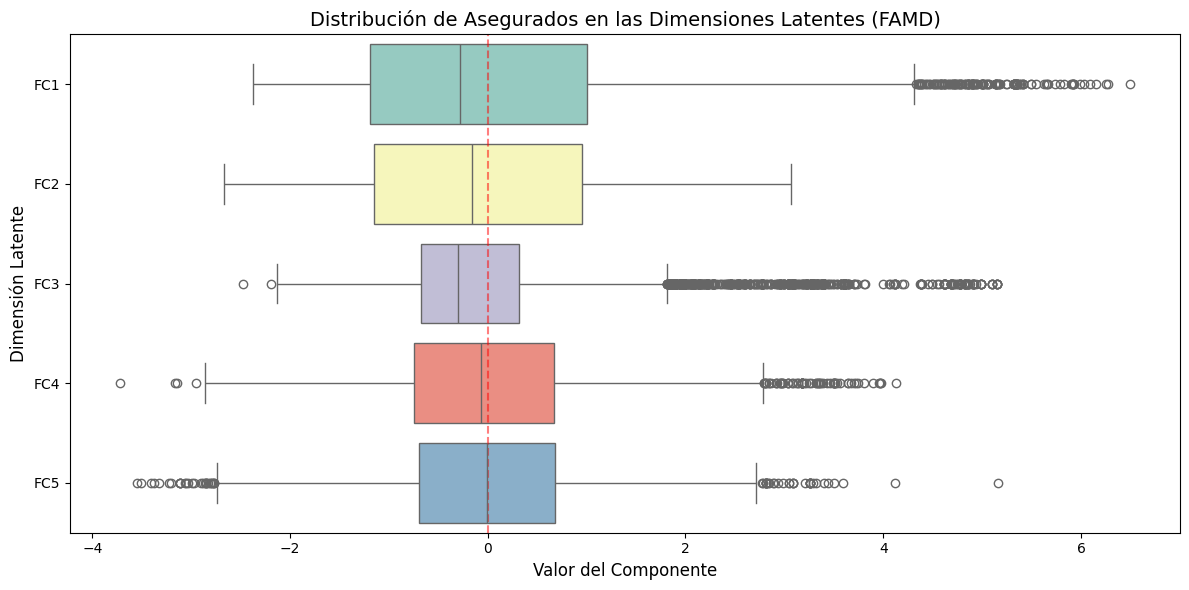

In [3]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, palette="Set3", orient='h')
plt.title('Distribución de Asegurados en las Dimensiones Latentes (FAMD)', fontsize=14)
plt.xlabel('Valor del Componente', fontsize=12)
plt.ylabel('Dimensión Latente', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [4]:
print("--- REPORTE DE OUTLIERS EXTREMOS (Z-Score > 3) ---")
columnas = ['FC1', 'FC2', 'FC3', 'FC4', 'FC5']
for col in columnas:
    z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
    # Contamos cuántos asegurados exceden las 3 desviaciones estándar
    num_outliers = (z_scores > 3).sum()
    pct_outliers = (num_outliers / len(df)) * 100
    print(f"{col}: {num_outliers} asegurados ({pct_outliers:.2f}%) con comportamiento extremo.")

--- REPORTE DE OUTLIERS EXTREMOS (Z-Score > 3) ---
FC1: 123 asegurados (1.37%) con comportamiento extremo.
FC2: 0 asegurados (0.00%) con comportamiento extremo.
FC3: 202 asegurados (2.25%) con comportamiento extremo.
FC4: 46 asegurados (0.51%) con comportamiento extremo.
FC5: 26 asegurados (0.29%) con comportamiento extremo.


El porcentaje de asegurados con comportamientos anómalos está por debajo del 3% en cada factor, lo cual nos parece un comportamiento admisible. También veremos si hay alguna perona que resulte atípica en varios factores a la vez.

In [5]:
z_scores_df = np.abs((df[columnas] - df[columnas].mean()) / df[columnas].std())
outliers_mask = (z_scores_df > 3)
severos = (outliers_mask.sum(axis=1) >= 2).sum()

print("\n--- CONCLUSIÓN MULTIVARIANTE ---")
print(f"Asegurados atípicos en 2 o más dimensiones: {severos} ({(severos / len(df)) * 100:.2f}%)")


--- CONCLUSIÓN MULTIVARIANTE ---
Asegurados atípicos en 2 o más dimensiones: 18 (0.20%)


De nuevo, no es un porcentaje preocupante. Nuesras variables parecen válidas para segmentar usando _K-means_

##### Comprobación de factores estandarizados
Antes de hacer _K-Means_ es importante comprobar que los factores tienen media 0 y varianza 1 ara asegurar que ninguna variable domina sobre las otras.

In [6]:
df_seg = df[columnas].copy()

for col in df_seg.columns:
    st_dv = df_seg[col].std()
    media = df_seg[col].mean()

    esta_centrada = np.isclose(media, 0, atol=1e-7)
    esta_escalada = np.isclose(st_dv, 1, atol=1e-7)
    
    if not (esta_centrada and esta_escalada):
        print(f"⚠️ El factor {col} REQUIERE estandarización (Media: {media:.2f}, STD: {st_dv:.2f})")

⚠️ El factor FC1 REQUIERE estandarización (Media: 0.00, STD: 1.53)
⚠️ El factor FC2 REQUIERE estandarización (Media: -0.00, STD: 1.33)
⚠️ El factor FC3 REQUIERE estandarización (Media: -0.00, STD: 1.09)
⚠️ El factor FC4 REQUIERE estandarización (Media: -0.00, STD: 1.05)
⚠️ El factor FC5 REQUIERE estandarización (Media: -0.00, STD: 1.03)


Los Factores devueltos por el FAMD están centrados pero no tienen varianza 1, es por tanto necesario estandarizarlos antes de empezar con la segmentación.

In [7]:
scaler = StandardScaler()
df_seg_scaled = pd.DataFrame(scaler.fit_transform(df_seg), columns=df_seg.columns, index=df_seg.index)
for col in df_seg.columns:
    st_dv = df_seg_scaled[col].std()
    media = df_seg_scaled[col].mean()
    print(f"[{col}] ---> Media: {media:.2f}, STD: {st_dv:.2f}")

[FC1] ---> Media: 0.00, STD: 1.00
[FC2] ---> Media: -0.00, STD: 1.00
[FC3] ---> Media: -0.00, STD: 1.00
[FC4] ---> Media: 0.00, STD: 1.00
[FC5] ---> Media: -0.00, STD: 1.00


### 2. Determinar Nº de Clusters

Debemos encontrar un número de perfiles de riesgo que suponga un trade off adecuado entre la matemática y el sentido actuarial. Debe responder ante las intuiciones de negocio sin perder de vista la matemática detrs del algoritmo. Para ello nos apoyamos entres pilares:
- El _Coeficiente de Silhouette_. Esta métrica evalúa la calidad del agrupamiento en base a la cohesión entre los asegurados de cada grupo y la separación entre los asegurados de grupos distintos. Se suelen tomar los valores más altos.
- El Método del Codo. Es menos robusto que _Shilouette_ pero más visual, toma en cuenta la varianza y busca el punto de inflexión en el que seguir añadiendo grupos no consigue que se reduzca la varianza, esto es el punto en el que la gráfica que veremos a continuación se aplana.
- Criterio Actuarial enfocado en el negocio. Debemos obtener un número de grupos suficiente para representar al total de la cartera de una forma equilibrada. No debemos caer en un exceso de grupos ni usar demasiado pocos.

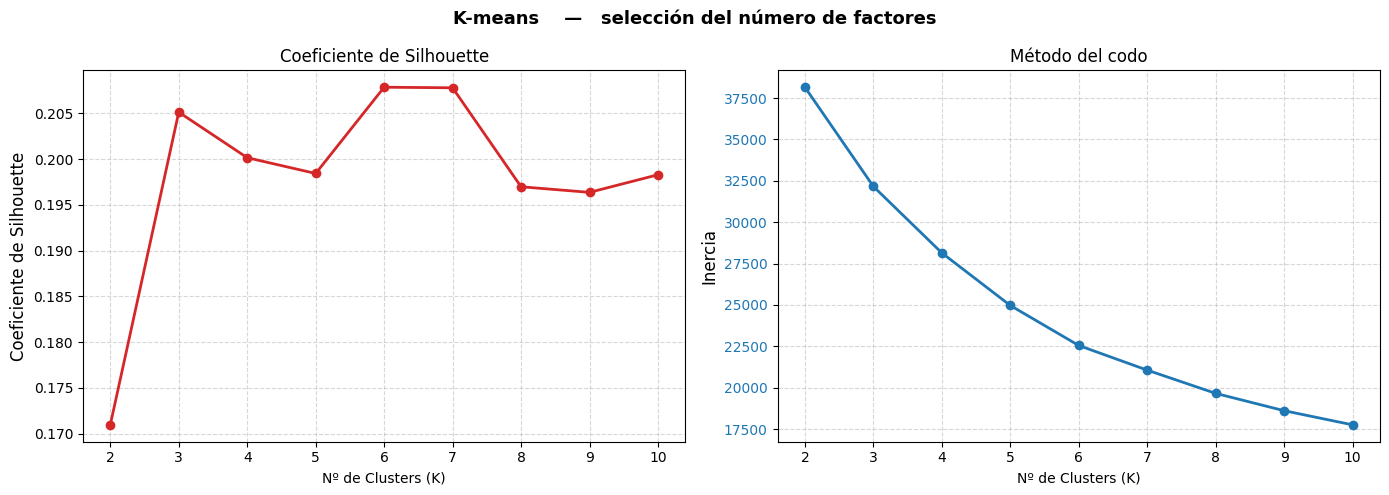

In [8]:
inercia = []
silhouette_avg = []
k_range = range(2, 11) # Probamos de 2 a 10 clústeres

for k in k_range:
    # Ajustamos K-means
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_seg_scaled)
    
    # Métrica 1: Inercia (Codo)
    inercia.append(kmeans.inertia_)
    
    # Métrica 2: Coeficiente de Silhouette
    silhouette_avg.append(silhouette_score(df_seg_scaled, cluster_labels))

########## VISUALIZACIÓN DE MÉTRICAS ##########

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico de silhouette --- #
axes[0].set_xlabel("Nº de Clusters (K)")
axes[0].set_ylabel('Coeficiente de Silhouette', fontsize=12)
axes[0].plot(k_range, silhouette_avg, marker='o', color='tab:red', linewidth=2)
axes[0].tick_params(axis='y')
axes[0].set_title("Coeficiente de Silhouette")
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Gráfico del codo --- #
axes[1].set_xlabel("Nº de Clusters (K)")
axes[1].set_ylabel('Inercia', fontsize=12)
axes[1].plot(k_range, inercia, marker='o', color='tab:blue', linewidth=2)
axes[1].tick_params(axis='y', labelcolor='tab:blue')
axes[1].set_title("Método del codo")
axes[1].grid(True, linestyle='--', alpha=0.5)




plt.suptitle("K-means    —   selección del número de factores",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


El gráfico se silhouette tiene un máximo local en 3 y un máximo local en 6 y 7. El gráfico de inercia muestra un descenso muy pronunciado hasta 3 y este descenso sigue siendo notable para 4 y 5 grupos. Vamos a probar una segmentación con 3 y otra con 6 grupos y comprobar cual nos ofrece una mejor visión de la cartera de clientes.

> Mientras que en teoría un valor del coeficiente de Silhouette < $0.25$ indica una estructura de clústeres débil, en modelos de **seguros de auto** es habitual encontrar valores en el intervalo $(0.1, 0.2)$. 

### 3. Segmentación

Llevamos a cabo la segmentación, visualizamos la separación de los grupos sobre un gráfico y cruzamos los grupos con algunas de nuestras variables para comprobar si tienen sentido.

In [9]:
# --- Aplicar K-means con k=3 --- #
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_3'] = kmeans_3.fit_predict(df_seg_scaled)
# df_seg_scaled['cluster_3'] = kmeans_3.fit_predict(df_seg_scaled)

# --- Aplicar K-means con k=5 --- #
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster_6'] = kmeans_6.fit_predict(df_seg_scaled)
# df_seg_scaled['cluster_5'] = kmeans_5.fit_predict(df_seg_scaled)

print(f"{'='*30}")
print(f"DISTRIBUCIÓN DE SEGMENTOS")
print(f"{'='*30}")

# Segmentación con 3 Clústeres
print("Resumen Cluster 3:")
print(df['cluster_3'].value_counts().to_frame('Cant').assign(Pct=lambda x: (x/x.sum()*100).round(2).astype(str) + '%'))

# Segmentación con 5 Clústeres
print("\nResumen Cluster 6:")
print(df['cluster_6'].value_counts().to_frame('Cant').assign(Pct=lambda x: (x/x.sum()*100).round(2).astype(str) + '%'))

DISTRIBUCIÓN DE SEGMENTOS
Resumen Cluster 3:
           Cant     Pct
cluster_3              
2          4988   55.6%
1          2402  26.78%
0          1581  17.62%

Resumen Cluster 6:
           Cant     Pct
cluster_6              
5          2363  26.34%
4          1758   19.6%
2          1740   19.4%
3          1369  15.26%
1           898  10.01%
0           843    9.4%


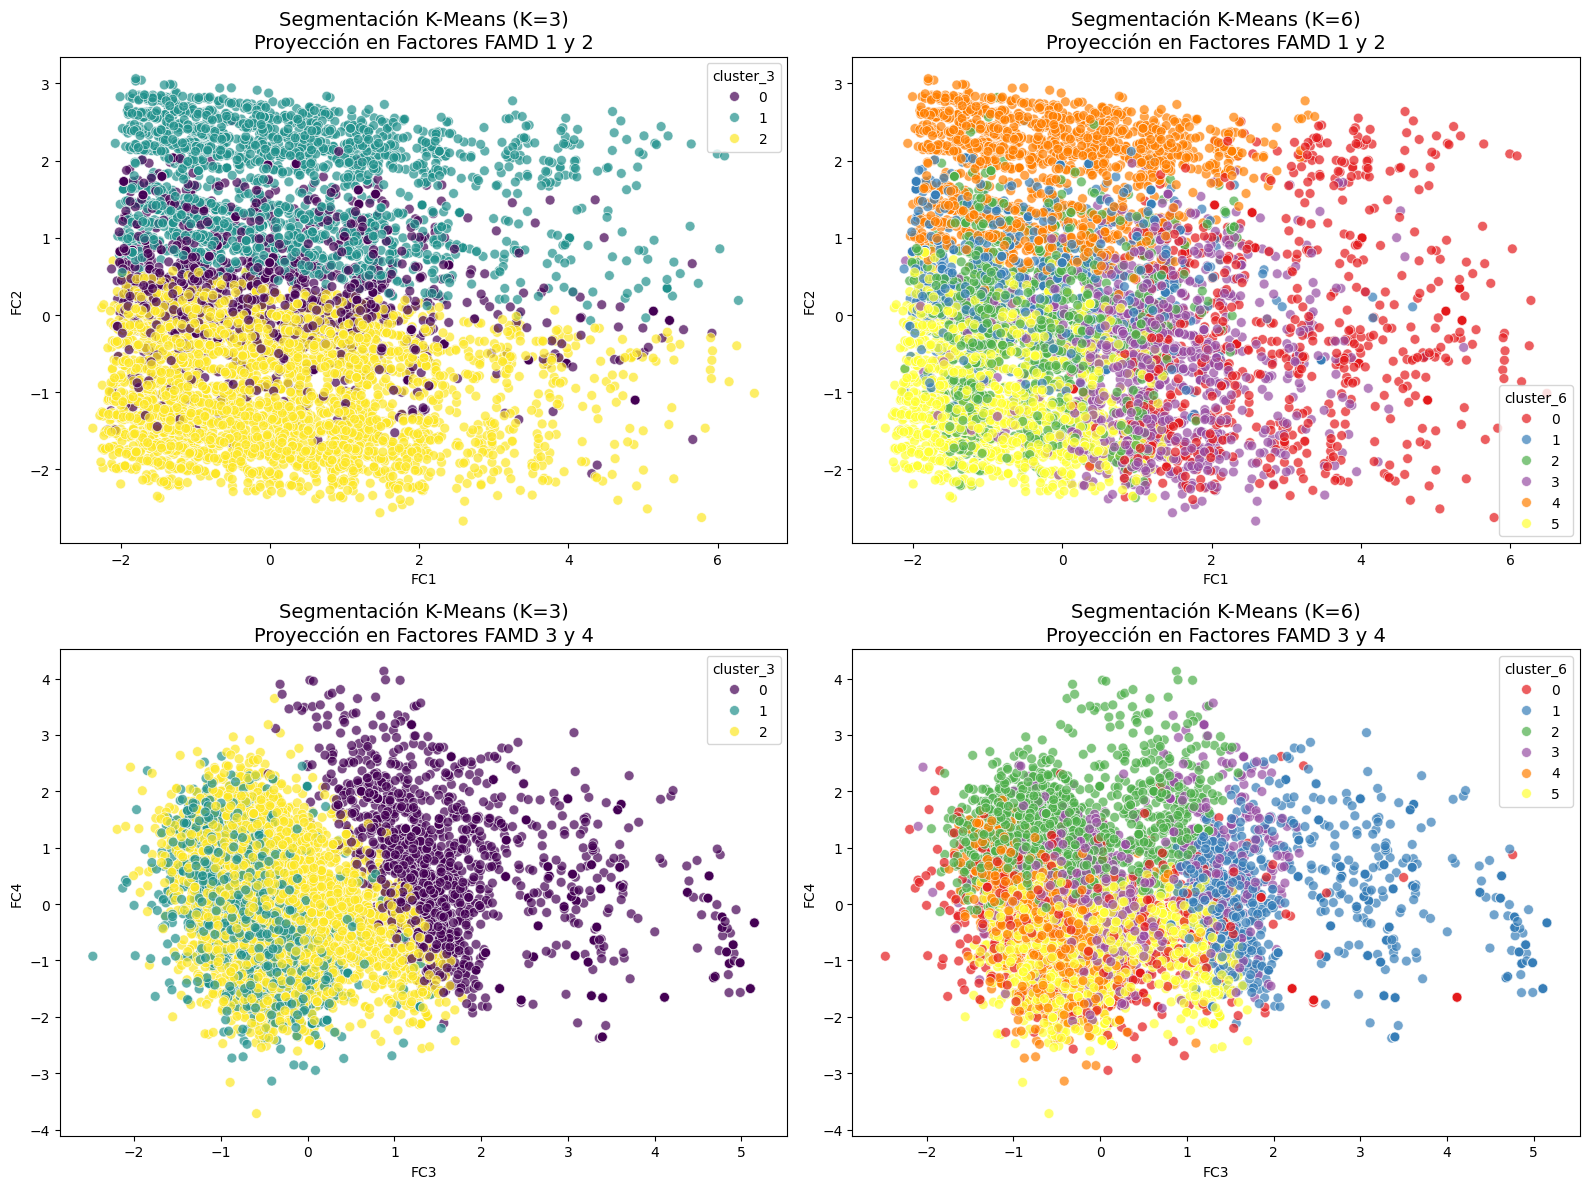

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico para K=3
sns.scatterplot(
    data=df, x='FC1', y='FC2', hue='cluster_3', 
    palette='viridis', ax=axes[0,0], s=50, alpha=0.7
)
axes[0,0].set_title('Segmentación K-Means (K=3)\nProyección en Factores FAMD 1 y 2', fontsize=14)
axes[0,0].set_xlabel('FC1')
axes[0,0].set_ylabel('FC2')

# Gráfico para K=6
sns.scatterplot(
    data=df, x='FC1', y='FC2', hue='cluster_6', 
    palette='Set1', ax=axes[0,1], s=50, alpha=0.7
)
axes[0,1].set_title('Segmentación K-Means (K=6)\nProyección en Factores FAMD 1 y 2', fontsize=14)
axes[0,1].set_xlabel('FC1')
axes[0,1].set_ylabel('FC2')


# Gráfico para K=3
sns.scatterplot(
    data=df, x='FC3', y='FC4', hue='cluster_3', 
    palette='viridis', ax=axes[1,0], s=50, alpha=0.7
)
axes[1,0].set_title('Segmentación K-Means (K=3)\nProyección en Factores FAMD 3 y 4', fontsize=14)
axes[1,0].set_xlabel('FC3')
axes[1,0].set_ylabel('FC4')

# Gráfico para K=6
sns.scatterplot(
    data=df, x='FC3', y='FC4', hue='cluster_6', 
    palette='Set1', ax=axes[1,1], s=50, alpha=0.7
)
axes[1,1].set_title('Segmentación K-Means (K=6)\nProyección en Factores FAMD 3 y 4', fontsize=14)
axes[1,1].set_xlabel('FC3')
axes[1,1].set_ylabel('FC4')


plt.tight_layout()
plt.show()

##### Métricas Estadísticas de Segmentación
Además del coeficiente de Silhouette y de la Inercia, validamos nuestro cluster con dos métricas:
- **El coeficiente Calinski-Harabasz.**. Indica que los grupos están bien separados y son compactos. Buscamos un valor alto.
- **El coeficiente Davies-Bouldin**. Mide la "similitud" promedio entre cada clúster y su clúster más parecido. Un valor nos indicará que los clusters no se confunden entre sí.

In [11]:
metrics_3 = {
    "Calinski-Harabasz": calinski_harabasz_score(df_seg_scaled, df['cluster_3']),
    "Davies-Bouldin": davies_bouldin_score(df_seg_scaled, df['cluster_3'])
}

metrics_6 = {
    "Calinski-Harabasz": calinski_harabasz_score(df_seg_scaled, df['cluster_6']),
    "Davies-Bouldin": davies_bouldin_score(df_seg_scaled, df['cluster_6'])
}
print('--- MÉTRICAS PARA K = 3 ---')
for metric, value in metrics_3.items():
    print(f"Índice {metric}: {value:.2f}")

print()

print('--- MÉTRICAS PARA K = 6 ---')
for metric, value in metrics_6.items():
    print(f"Índice {metric}: {value:.2f}")

--- MÉTRICAS PARA K = 3 ---
Índice Calinski-Harabasz: 1770.24
Índice Davies-Bouldin: 1.69

--- MÉTRICAS PARA K = 6 ---
Índice Calinski-Harabasz: 1773.70
Índice Davies-Bouldin: 1.31


##### Resultado Estadístico
| **Índice** | **Valor k = 3** | **Valor k = 6** | **Interpretación** |
| --- | --- | --- | --- |
| Calinski-Harabasz | 1770.24  | 1773.7 | Son valores altos, la dispersión intracluster es mucho menor que la dispersión entre clusters. |
| Davies-Bouldin | 1.69  | 1.31 | Son valores menores que 1 los centros de los clusters están separados pero las fronteras son difusas -> Valida el futuro uso de una BNN |

La decisión es tomar 6 grupos en lugar de 3:
- Observando los gráficos, parece haber una una separación mucho más clara en la segmentación de 3. Por contra Davies-Bouldin nos muestran que esta separación es mayor al tomar 6 grupos.


Podemos decir que la segmentación en 6 grupos es robusta. Hemos pasado de tener una masa de 9,000 datos a tener seis Grupos de Riesgo.

### 5. Validación de los Segmentos respecto a la Severidad Total
Para nuestro propósito de crear perfiles de riesgo es crucial que los seis grupos que hemos propuesto tengan una severidad claramente diferenciada. Realizaremos algunas pruebas sobre la variable `Total Claim Amount` y nuestros nuevos segmentos para comrprobar que estos segmentos son válidos desde la perspectiva de negocio.

##### Prueba de Kruskal-Wallis
Como hemos visto en el paso la variable `Total Claim Amount` no siguue una distribución normal, por ello comprobamos que los seis grupos tienen severidades significativamente distinas haciendo un test no paramétrico como _Kruskal-Wallis_

In [12]:
# Recuperamos la variable objetivo: Total Claim Amount
df_obj = pd.read_csv(DATA_PATH + 'y_target.csv')
df_final = pd.merge(df.drop(columns = ['cluster_3']), df_obj, on='Customer', how='left')

# --- Prueba de Kruskal-Wallis ---
grupo_0 = df_final[df_final['cluster_6'] == 0]['Total Claim Amount']
grupo_1 = df_final[df_final['cluster_6'] == 1]['Total Claim Amount']
grupo_2 = df_final[df_final['cluster_6'] == 2]['Total Claim Amount']

stat, p_value = kruskal(grupo_0, grupo_1, grupo_2)
print(f"\nPrueba de Kruskal-Wallis: Stat={stat:.2f}, p-valor={p_value:.4e}")


Prueba de Kruskal-Wallis: Stat=474.33, p-valor=1.0028e-103


Un p-valor menor que 0.05 rechaza la hipótesis nula de que los segmentos tengan severidades estadísticamente iguales. Veamos a continuación que valores toma la severidad para cada grupo.

##### Estadísticos descriptivos

In [13]:
# --- Estadísticos Descriptivos ---
resumen_severidad = df_final.groupby('cluster_6')['Total Claim Amount'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
resumen_severidad['CV'] = resumen_severidad['std'] / resumen_severidad['mean']
print("Análisis de Severidad por Clúster:")
print(resumen_severidad)

Análisis de Severidad por Clúster:
           count        mean  median         std    min      max        CV
cluster_6                                                                 
0            843  729.660949  637.06  508.189405   1.59  2893.24  0.696473
1            898  459.619465  421.94  180.841892   8.74  1404.00  0.393460
2           1740  356.642299  345.21  169.818089   0.10  1257.53  0.476158
3           1369  511.385551  513.60  229.115367   0.52  2069.31  0.448029
4           1758  576.748294  511.26  245.396931  25.81  2156.01  0.425484
5           2363  224.284901  207.75  149.487713   0.38   905.70  0.666508


##### Boxplot

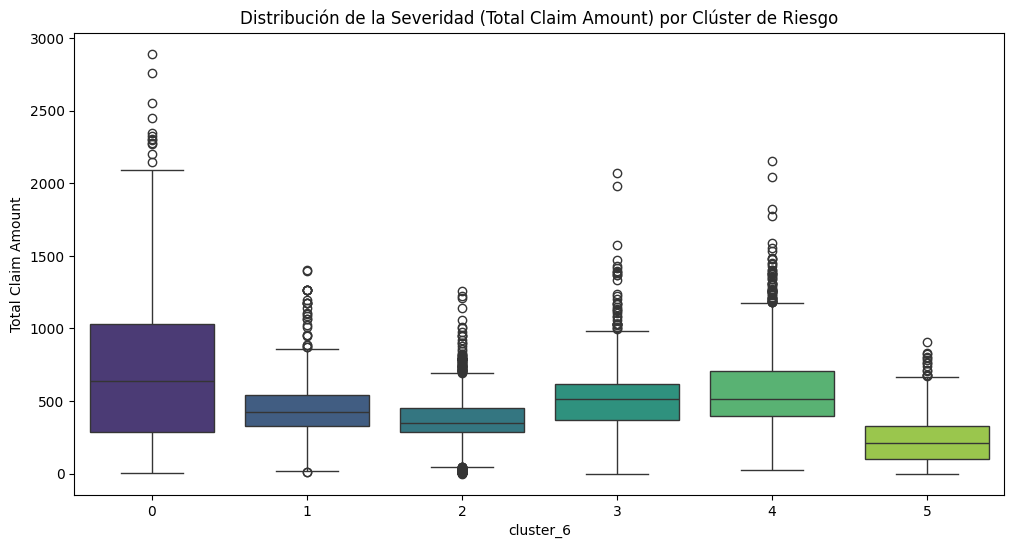

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='cluster_6', y='Total Claim Amount', data=df_final, palette='viridis')
plt.title('Distribución de la Severidad (Total Claim Amount) por Clúster de Riesgo')
plt.show()

##### Conclusiones
- Cluster 0.  Son el grupo más disperso, tienen la severidad media más alta y la cola más larga. Es el grupo menos numeroso
- Cluster 1. Tiene una severidad media en comparación con los demás grupos, su CV es el más bajo. Junto con el cluster 0 es el grupo menos numeroso
- Cluster 2. Su severidad es bastante baja en comparación con los demás grupos a excepción del 5.
- Clusters 3 y 4. Su distribución de severidad es bastante parecida, son grupos que debemos observar en que se diferencian en el perfilado.
- Cluster 5. Es el grupo con la severidad media más baja.

A priori los distintos grupos siguen distintas distribuciones de severidad.

### 6. Perfilado de los Segmentos

Para obtener una mejor interpretación de cada uno de los segmentos cruzaremos los grupos con algunas de las variables para saber que tipos de personas comforma cada cluster.

In [15]:
# --- Creación del df con todas las variables --- #
estratificadores = pd.read_csv(DATA_PATH + 'estratificadores.csv')
df_completo = pd.merge(df_final, estratificadores, on='Customer', how='left')

# 3. Definición de variables para el profiling
numericas = ['Customer Lifetime Value', 'Income', 'Monthly Premium Auto', 'Months Since Last Claim', 
            'Months Since Policy Inception', 'Total Claim Amount']

nominales = ['State', 'Coverage', 'Education', 'EmploymentStatus', 'Gender', 'Location Code', 
            'Marital Status', 'Policy Type', 'Vehicle Class', 'Vehicle Size', 'Number of Open Complaints', 'Number of Policies']

# Lista para almacenar los "bloques" de datos antes de unirlos
bloques_resultados = []

# 2. Procesar las variables numéricas (Media)
for col in numericas:
    if col in df_completo.columns:
        # Calcular la media por cada cluster
        media = df_completo.groupby('cluster_6')[col].mean()
        # Convertir a DataFrame y transponer (para que los clusters sean las columnas)
        df_temp = pd.DataFrame(media).T
        # Crear un MultiÍndice: Nivel 1 = Nombre Variable, Nivel 2 = "Media"
        df_temp.index = pd.MultiIndex.from_tuples([(col, 'Media')], names=['Variable', 'Item/Métrica'])
        bloques_resultados.append(df_temp)

# 3. Procesar las variables nominales (% sobre el total del cluster)
for col in nominales:
    if col in df_completo.columns:
        # Calcular tabla cruzada. 
        # normalize='columns' divide cada valor entre el total de su respectiva columna (clúster)
        # Multiplicamos por 100 para tenerlo en formato porcentaje (0 - 100%)
        ct = pd.crosstab(df_completo[col], df_completo['cluster_6'], normalize='columns') * 100
        # Crear un MultiÍndice: Nivel 1 = Nombre Variable, Nivel 2 = Categorías/Ítems de la variable
        ct.index = pd.MultiIndex.from_product([[col], ct.index], names=['Variable', 'Item/Métrica'])
        bloques_resultados.append(ct)

# 4. Unir todos los bloques en un solo DataFrame
df_resultados_final = pd.concat(bloques_resultados)

# Opcional: redondear los valores a 2 decimales para que el Excel quede más limpio
df_resultados_final = df_resultados_final.round(2)

# 5. Exportar a Excel
# nombre_archivo = 'tabla_cruzada_clusters_6.xlsx'
# df_resultados_final.to_excel(OUTPUT_DIR + nombre_archivo)

# print(f"El archivo {nombre_archivo} se ha generado correctamente.")

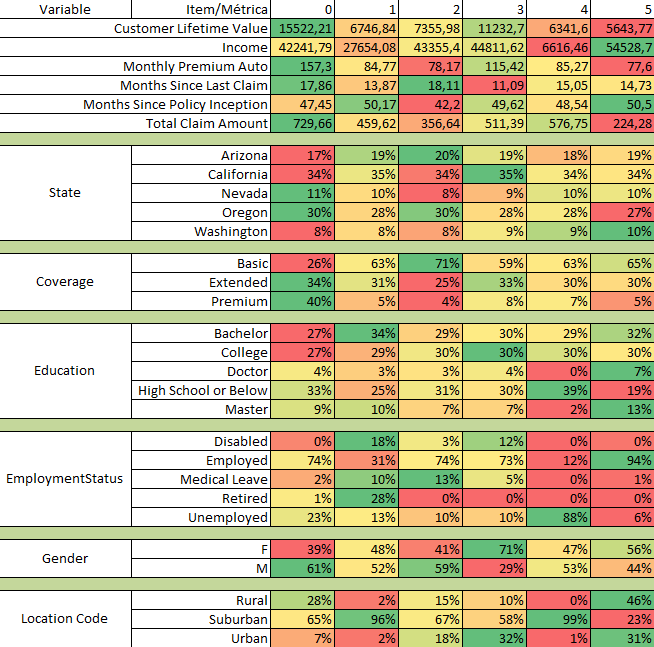  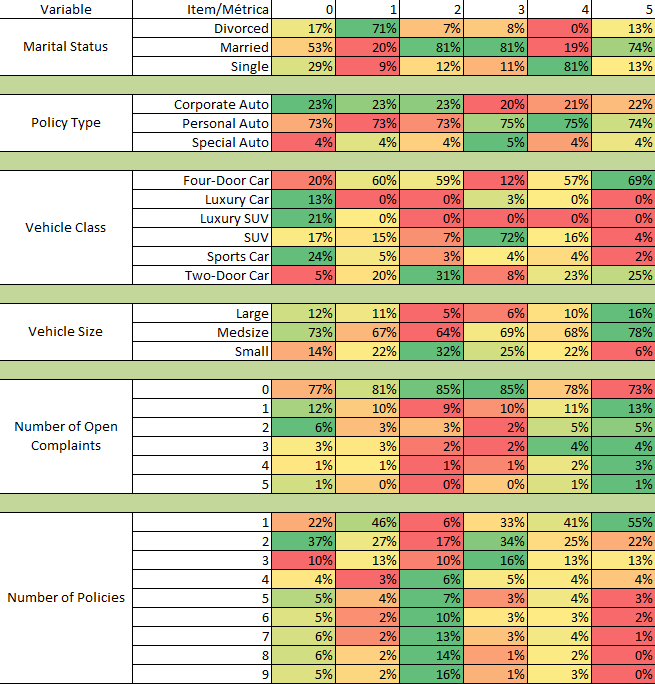


En vista de las tablas podemosperfilar los grupos propuestos con los siguientes nombres y descripciones:
| Nº de cluster | Nombre | Descripción |
| :--- | :--- | :--- |
| **0** | **Risky Elites** | Es el grupo más rentable por prima (CLV y Premium más altos), pero también el más costoso en siniestros. Son conductores de lujo/deportivos que asumen riesgos. |
| **1** | **Suburban Seniors** | Clientes con educación universitaria, mayoritariamente jubilados o de baja, que viven en la periferia. Tienen un perfil de riesgo moderado y baja vinculación. |
| **2** | **Budget Pragmatists** | Hombres casados con coches pequeños y seguros básicos. Buscan el precio más bajo posible, tienen muchos seguros pero generan pocos gastos por siniestros. |
| **3** | **Urban Upscales** | Perfil familiar (SUVs) y mayoritariamente femenino. Es el segundo grupo más valioso; prefieren coberturas extendidas y tienen una estabilidad económica media-alta. |
| **4** | **Vulnerable Risks** | El grupo con menores ingresos y educación. A pesar de pagar primas bajas, su siniestralidad es desproporcionadamente alta, lo que los hace poco rentables. |
| **5** | **Secure Scholars** | Clientes con máxima formación e ingresos que apenas usan el seguro (siniestralidad mínima). Aunque su CLV es bajo por pagar primas básicas. |

### 7. Motor de Clasificación
Una vez hemos validado nuestros segmentos y perfilado que tipo de clientes hay en cada clase de riesgo, creamos un motor de clasificación. Guardamos los centroides originales de la segmentación _k-means_ y reclasificamos nuestra cartera respecto a estos centroides. Al hacer esto obtendremos los siguientes beneficios:
1. Un fragmento de código que asegura la reproducibilidad de los mismos perfiles de riesgo para futuros clientes en lugar de reentrenar y crear una nueva segmentación que validar y perfilar. 
2. Una métrica de la distancia a la que se encuentra cada cliente del centroide del grupo que se le ha asignado, lo que podemos intrpretar como la seguridad que tenemos de que ese cliente pertenezca a la clase de riesgo asignada, a menor valor más cerca del centroide y en consecuencia más seguros de que pertenece a dicha clase de riesgo; será de utilidad en la BNN.
3. Inmutabilidad del resultado, el algoritmo _K-means_ se encarga de clasificar cada uno de los clientes en el segmento cuyo centroide es el más cercano. Al ejecutar el motor de clasificación sobre nuestra cartera de clientes no deberíamos observar variaciones sobre las clases que hemos validado.

In [16]:
# --- Extracción de Centroides --- #
centroids = kmeans_6.cluster_centers_

# --- Función de Clasificación --- #
def predict_risk_profile(data_pca, centroids):
    # Calcula distancias a los 3 centros
    distances = np.linalg.norm(data_pca[:, np.newaxis] - centroids, axis=2)
    # Asigna el clúster más cercano
    cluster_assigned = np.argmin(distances, axis=1)
    # Retorna la etiqueta y la 'confianza' (qué tan cerca está del centro)
    confidence = np.min(distances, axis=1)
    return cluster_assigned, confidence

# --- Reclasificación de la Cartera --- #
df['Cluster_Final'], df['Atipicidad'] = predict_risk_profile(df_seg_scaled.values, centroids)
df = df.copy().drop(columns = ['cluster_3'])

##### Validación de los Segmentos Reclasificados

In [17]:
if len(df[df['cluster_6'] != df['Cluster_Final']]) == 0:
    print('¡ÉXITO! La clasificación coincide con el clustering original')
    df = df.drop(columns = ['cluster_6'])
else:
    print('¡REVISAR! Hay individuos clasificados en grupos distintos al asignado en k-means')

¡ÉXITO! La clasificación coincide con el clustering original


##### Generación de Outputs


In [18]:
# --- Factores PCA y Cluster --- #
df.to_excel(OUTPUT_DIR + 'factores_cluster.xlsx')

# --- Todas las Vbles y Cluster --- #
df_completo = df_completo.drop(columns=['cluster_6']).merge(
    df[['Customer', 'Cluster_Final', 'Atipicidad']], 
    on='Customer', how='left'
)
df_completo['Atipicidad'] = df['Atipicidad']
df_completo.to_excel(OUTPUT_DIR + 'vbles_og_cluster.xlsx')

# --- Cluster e ID --- #
df_completo[['Customer', 'Cluster_Final', 'Atipicidad']].to_excel(OUTPUT_DIR + 'id_clasificado.xlsx')